In [43]:
import sys
print(sys.path)

['/usr/local/lib/python311.zip', '/usr/local/lib/python3.11', '/usr/local/lib/python3.11/lib-dynload', '', '/home/vscode/.local/lib/python3.11/site-packages', '/usr/local/lib/python3.11/site-packages', '/workspaces/Plasma', '/workspaces/Plasma']


In [44]:
import os
sys.path.append(os.path.abspath(".."))

In [45]:
import importlib
from resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.optim as optim

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [48]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [49]:
g.r_grid

array([[0.84      , 0.84      , 0.84      , ..., 0.84      , 0.84      ,
        0.84      ],
       [0.85328125, 0.85328125, 0.85328125, ..., 0.85328125, 0.85328125,
        0.85328125],
       [0.8665625 , 0.8665625 , 0.8665625 , ..., 0.8665625 , 0.8665625 ,
        0.8665625 ],
       ...,
       [2.5134375 , 2.5134375 , 2.5134375 , ..., 2.5134375 , 2.5134375 ,
        2.5134375 ],
       [2.52671875, 2.52671875, 2.52671875, ..., 2.52671875, 2.52671875,
        2.52671875],
       [2.54      , 2.54      , 2.54      , ..., 2.54      , 2.54      ,
        2.54      ]], shape=(129, 129))

In [50]:
r = np.concatenate(g.r_grid)
print(r.shape)

(16641,)


In [51]:
z = np.concatenate(g.z_grid)
X_train = np.column_stack((r, z))
Y_train = np.concatenate(psi_norm)
BR_train  = np.concatenate(BR)
BZ_train = np.concatenate(BZ)

In [52]:
# NN
class PsiNN(nn.Module):
  def __init__(self):
    super(PsiNN, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(2, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 1)

    )
  def forward(self, x):
    return self.model(x)

In [53]:
# Initialize model, loss, and optimizer
model_psi = PsiNN()
fn_Loss = nn.MSELoss()
model_psi.to(device)
optimizer = optim.Adam(model_psi.parameters(), lr=0.001)

In [54]:
Y_train.dtype

dtype('float64')

In [55]:
Y_train = Y_train.reshape(-1,1)
Y_train.shape

(16641, 1)

In [56]:
# Move X_train to the device as well
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
# Move y_train to the device as well
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)

# Training loop
epochs = 10001
for epoch in range(epochs):
  model_psi.train()
  Y_preds = model_psi(X_train)
  loss = fn_Loss(Y_preds, Y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.25724831223487854
Epoch 100, Loss: 0.00438625318929553
Epoch 200, Loss: 0.0007497759652324021
Epoch 300, Loss: 0.00048154403339140117
Epoch 400, Loss: 0.0003679102810565382
Epoch 500, Loss: 0.0002822667302098125
Epoch 600, Loss: 0.00022001838078722358
Epoch 700, Loss: 0.00017933292838279158
Epoch 800, Loss: 0.0001497309422120452
Epoch 900, Loss: 0.00012843152217101306
Epoch 1000, Loss: 0.00010920008935499936
Epoch 1100, Loss: 9.760434477357194e-05
Epoch 1200, Loss: 8.755194721743464e-05
Epoch 1300, Loss: 8.22015936137177e-05
Epoch 1400, Loss: 8.668779628351331e-05
Epoch 1500, Loss: 8.760801574680954e-05
Epoch 1600, Loss: 7.132966857170686e-05
Epoch 1700, Loss: 7.237835234263912e-05
Epoch 1800, Loss: 6.712398317176849e-05
Epoch 1900, Loss: 7.622471457580104e-05
Epoch 2000, Loss: 6.412060611182824e-05
Epoch 2100, Loss: 0.000174456654349342
Epoch 2200, Loss: 6.307668081717566e-05
Epoch 2300, Loss: 5.984910603729077e-05
Epoch 2400, Loss: 7.758102583466098e-05
Epoch 2500, L

In [ ]:
# Training



In [57]:
# Compute final MSE loss
model_psi.eval()
with torch.no_grad():
  Y_final = model_psi(X_train)
  loss = fn_Loss(Y_final, Y_train)
  loss_psi_vanilla = loss.item() * 100
  print(f"Final MSE Loss for (R, Z) -> psi (in %): {loss_psi_vanilla}")

Final MSE Loss for (R, Z) -> psi (in %): 0.003948498851968907


In [58]:
psi = Y_final.reshape(129,129)

In [59]:
def plot_psi(R ,Z, psi_preds, title):
  plt.contourf(R, Z, psi_preds,  cmap = 'plasma')
  plt.colorbar()
  plt.xlim([R[0],R[-1]])
  plt.ylim([Z[0],Z[-1]])
  plt.xlabel('R [m]')
  plt.ylabel('Z [m]')
  plt.axis('equal')
  plt.title(title)

/tmp/ipykernel_7475/4280469088.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plot_psi(g.r_grid[:, 0], g.z_grid[0, :], (abs(psi-psi_norm)*100).T, title=r"$\psi(R, Z)_{error}$")


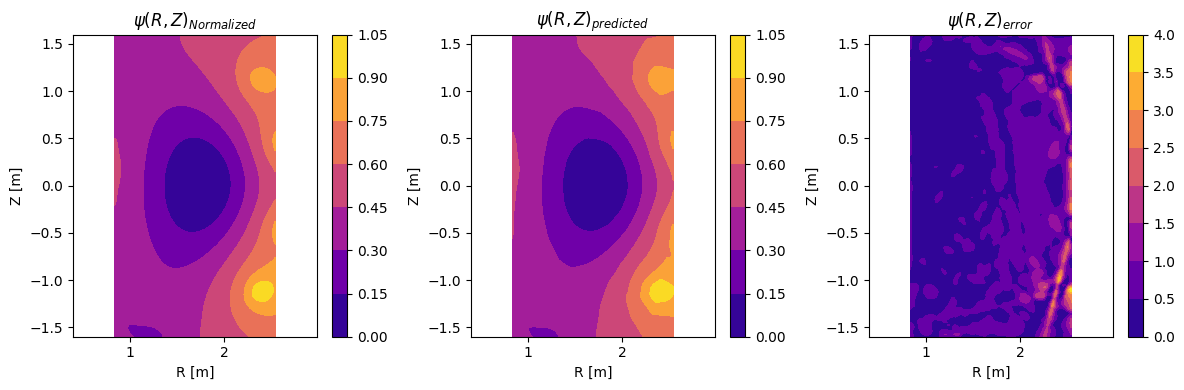

In [60]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plot_psi(g.r_grid[:, 0] ,g.z_grid[0, :], psi_norm.T, title = r"$\psi(R,Z)_{Normalized}$")

plt.subplot(1,3,2)
plot_psi(g.r_grid[:, 0] ,g.z_grid[0, :], psi.T, title = r"$\psi(R,Z)_{predicted}$")

plt.subplot(1,3,3)
plot_psi(g.r_grid[:, 0], g.z_grid[0, :], (abs(psi-psi_norm)*100).T, title=r"$\psi(R, Z)_{error}$")

plt.tight_layout()
plt.show()